In [3]:
import polars as pl

cresta = pl.read_parquet("../data/cresta/triad/staged/cresta_triad.conf.parquet")
cresta_new = pl.read_parquet(
    "../data/cresta_new/triad/staged/cresta_triad.conf.parquet"
)

In [10]:
cresta_new.select("job_name").join(
    cresta.select("job_name"),
    on="job_name",
)

job_name
str
"""a66e0e95993e71fef83d9f0951edb1…"
"""44ffbcb6d6b17f182063002435cf9a…"
"""1d3f838252cdf197332c0030f339f8…"
"""ddc0a3a94637f5f9fd9a36dda18451…"
"""4942b4cfc6b73b6ee99fbc44158e25…"
…
"""5133db4fb727bec24e06bc932f2f2f…"
"""b9a16457e058ccfb1a5bb37ac48d1e…"
"""3c19203b5c2596f2fc01e043ad9ae3…"


In [8]:
cresta.select("job_name")

job_name
str
"""a66e0e95993e71fef83d9f0951edb1…"
"""44ffbcb6d6b17f182063002435cf9a…"
"""1d3f838252cdf197332c0030f339f8…"
"""ddc0a3a94637f5f9fd9a36dda18451…"
"""4942b4cfc6b73b6ee99fbc44158e25…"
…
"""5133db4fb727bec24e06bc932f2f2f…"
"""b9a16457e058ccfb1a5bb37ac48d1e…"
"""3c19203b5c2596f2fc01e043ad9ae3…"


In [7]:
from tcrtrifold.eval_utils import antigen_raw_score_auc

antigen_raw_score_auc(
    cresta.with_columns((1 - pl.col("mean_p_tcr_pae")).alias("mean_p_tcr_pae")),
    "mean_p_tcr_pae",
)

peptide,mhc_class,mhc_1_chain,mhc_1_species,mhc_1_name,mhc_1_seq,mhc_2_chain,mhc_2_species,mhc_2_name,mhc_2_seq,mean_p_tcr_pae,fpr,tpr
str,str,str,str,str,str,str,str,str,str,f64,list[f64],list[f64]
"""MAMMARDTA""","""II""","""alpha""","""human""","""DRA1*01:02""","""KEEHVIIQAEFYLNPDQSGEFMFDFDGDEI…","""beta""","""human""","""DRB1*11:01""","""GDTRPRFLEYSTSECHFFNGTERVRFLDRY…",0.69898,"[0.0, 0.0, … 1.0]","[0.0, 0.071429, … 1.0]"
"""SLRIAAKIY""","""II""","""alpha""","""human""","""DRA1*01:02""","""KEEHVIIQAEFYLNPDQSGEFMFDFDGDEI…","""beta""","""human""","""DRB1*11:01""","""GDTRPRFLEYSTSECHFFNGTERVRFLDRY…",0.869835,"[0.0, 0.0, … 1.0]","[0.0, 0.045455, … 1.0]"
"""VRFQEAANK""","""II""","""alpha""","""human""","""DRA1*01:02""","""KEEHVIIQAEFYLNPDQSGEFMFDFDGDEI…","""beta""","""human""","""DRB1*15:03""","""GDTRPRFLWQPKRECHFFNGTERVRFLDRH…",0.796296,"[0.0, 0.0, … 1.0]","[0.0, 0.055556, … 1.0]"
"""IAFASGFRA""","""II""","""alpha""","""human""","""DRA1*01:02""","""KEEHVIIQAEFYLNPDQSGEFMFDFDGDEI…","""beta""","""human""","""DRB1*01:02""","""GDTRPRFLWQLKFECHFFNGTERVRLLERC…",0.669421,"[0.0, 0.0, … 1.0]","[0.0, 0.090909, … 1.0]"
"""VMAYPEMLA""","""II""","""alpha""","""human""","""DRA1*01:02""","""KEEHVIIQAEFYLNPDQSGEFMFDFDGDEI…","""beta""","""human""","""DRB1*15:03""","""GDTRPRFLWQPKRECHFFNGTERVRFLDRH…",0.787721,"[0.0, 0.0, … 1.0]","[0.0, 0.016129, … 1.0]"
"""IRQAGVQYS""","""II""","""alpha""","""human""","""DQA1*01:02""","""EDIVADHVASCGVNLYQFYGPSGQYTHEFD…","""beta""","""human""","""DQB1*06:02""","""RDSPEDFVFQFKGMCYFTNGTERVRLVTRY…",0.792899,"[0.0, 0.0, … 1.0]","[0.0, 0.076923, … 1.0]"
"""VRFQEAANK""","""II""","""alpha""","""human""","""DRA1*01:02""","""KEEHVIIQAEFYLNPDQSGEFMFDFDGDEI…","""beta""","""human""","""DRB5*01:01""","""GDTRPRFLQQDKYECHFFNGTERVRFLHRD…",0.996599,"[0.0, 0.0, … 1.0]","[0.0, 0.02381, … 1.0]"
"""WNFAGIEAA""","""II""","""alpha""","""human""","""DQA1*01:02""","""EDIVADHVASCGVNLYQFYGPSGQYTHEFD…","""beta""","""human""","""DQB1*06:02""","""RDSPEDFVFQFKGMCYFTNGTERVRLVTRY…",0.847222,"[0.0, 0.0, … 1.0]","[0.0, 0.041667, … 1.0]"


## Compare total AUC


In [ ]:
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import RocCurveDisplay

cresta_focal = cresta.select((1 - pl.col("mean_p_tcr_pae")), "cognate").to_numpy()
cresta_new_focal = cresta_new.select(
    (1 - pl.col("mean_p_tcr_pae")), "cognate"
).to_numpy()

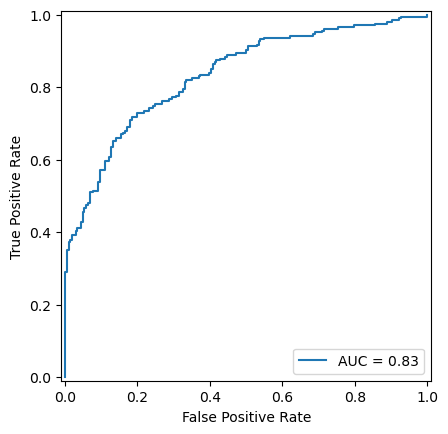

In [65]:
fpr, tpr, _ = roc_curve(cresta_focal[:, 1], cresta_focal[:, 0])
roc_auc = auc(fpr, tpr)

RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc).plot()

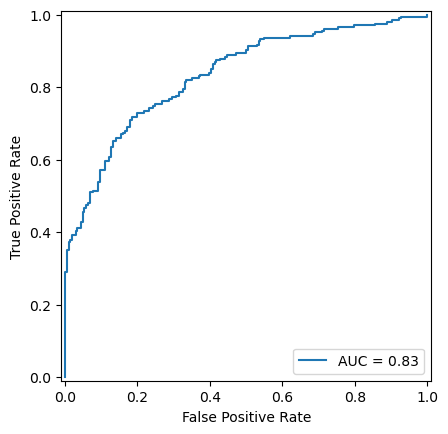

In [66]:
fpr_new, tpr_new, _ = roc_curve(cresta_new_focal[:, 1], cresta_new_focal[:, 0])
roc_auc_new = auc(fpr_new, tpr_new)

RocCurveDisplay(fpr=fpr_new, tpr=tpr_new, roc_auc=roc_auc_new).plot()

## DRB5\*01:01


In [60]:
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import RocCurveDisplay

cresta_focal = (
    cresta.filter(
        pl.col("peptide") == "VRFQEAANK", pl.col("mhc_2_name") == "DRB5*01:01"
    )
    .select((1 - pl.col("mean_p_tcr_pae")), "cognate")
    .to_numpy()
)
cresta_new_focal = (
    cresta_new.filter(
        pl.col("peptide") == "AVVRFQEAA", pl.col("mhc_2_name") == "DRB5*01:01"
    )
    .select((1 - pl.col("mean_p_tcr_pae")), "cognate")
    .to_numpy()
)

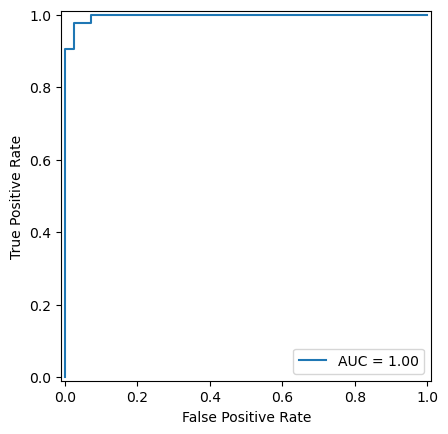

In [61]:
fpr, tpr, _ = roc_curve(cresta_focal[:, 1], cresta_focal[:, 0])
roc_auc = auc(fpr, tpr)

RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc).plot()

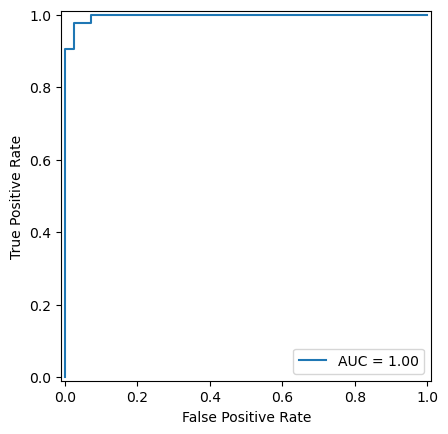

In [62]:
fpr_new, tpr_new, _ = roc_curve(cresta_new_focal[:, 1], cresta_new_focal[:, 0])
roc_auc_new = auc(fpr_new, tpr_new)

RocCurveDisplay(fpr=fpr_new, tpr=tpr_new, roc_auc=roc_auc_new).plot()

## DRB1\*15:03
